<a href="https://colab.research.google.com/github/bhashyadeep123-crypto/csot-ml-astronomy/blob/main/submissions/bhashyadeep123-crypto/week1/week1_data_starter_my_attempt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import random
from pathlib import Path

import pandas as pd
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import ImageFolder
import torchvision
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


In [ ]:
from pathlib import Path
RAW_ROOT = Path("/content/drive/MyDrive/galaxy_raw")
IMAGES_DIR = RAW_ROOT / "images_gz2" / "images"
DATA_ROOT = Path("/content/drive/MyDrive/galaxy_data")
print(RAW_ROOT.exists())
print(IMAGES_DIR.exists())
print((RAW_ROOT / "gz2_filename_mapping.csv").exists())
print((RAW_ROOT / "gz2_hart16.csv").exists())

True
True
True
True


In [ ]:
import os
from pathlib import Path
import pandas as pd
# 1. List files in RAW_ROOT
print("Contents of RAW_ROOT:")
print(os.listdir(RAW_ROOT))
# 2. Count JPG images
jpgs = list(Path(IMAGES_DIR).glob("*.jpg"))
print("\nNumber of JPG files:", len(jpgs))
# Show first 5 image names
print("\nFirst 5 images:")
for f in jpgs[:5]:
    print(f.name)
# 3. Open mapping CSV
mapping = pd.read_csv(RAW_ROOT / "gz2_filename_mapping.csv")

print("\nColumns in mapping file:")
print(mapping.columns.tolist())

print("\nFirst 5 rows:")
print(mapping.head())

Contents of RAW_ROOT:
['archive.zip', 'gz2_filename_mapping.csv', 'images_gz2.zip', 'images_gz2', 'gz2_hart16.csv']

Number of JPG files: 243434

First 5 images:
100.jpg
1000.jpg
10000.jpg
100000.jpg
100001.jpg

Columns in mapping file:
['objid', 'sample', 'asset_id']

First 5 rows:
                objid    sample  asset_id
0  587722981736120347  original         1
1  587722981736579107  original         2
2  587722981741363294  original         3
3  587722981741363323  original         4
4  587722981741559888  original         5


In [ ]:
import pandas as pd
hart = pd.read_csv(RAW_ROOT / "gz2_hart16.csv")
print(hart.columns.tolist())
hart.head()



['dr7objid', 'ra', 'dec', 'rastring', 'decstring', 'sample', 'gz2_class', 'total_classifications', 'total_votes', 't01_smooth_or_features_a01_smooth_count', 't01_smooth_or_features_a01_smooth_weight', 't01_smooth_or_features_a01_smooth_fraction', 't01_smooth_or_features_a01_smooth_weighted_fraction', 't01_smooth_or_features_a01_smooth_debiased', 't01_smooth_or_features_a01_smooth_flag', 't01_smooth_or_features_a02_features_or_disk_count', 't01_smooth_or_features_a02_features_or_disk_weight', 't01_smooth_or_features_a02_features_or_disk_fraction', 't01_smooth_or_features_a02_features_or_disk_weighted_fraction', 't01_smooth_or_features_a02_features_or_disk_debiased', 't01_smooth_or_features_a02_features_or_disk_flag', 't01_smooth_or_features_a03_star_or_artifact_count', 't01_smooth_or_features_a03_star_or_artifact_weight', 't01_smooth_or_features_a03_star_or_artifact_fraction', 't01_smooth_or_features_a03_star_or_artifact_weighted_fraction', 't01_smooth_or_features_a03_star_or_artifact_d

,dr7objid,ra,dec,rastring,decstring,sample,gz2_class,total_classifications,total_votes,t01_smooth_or_features_a01_smooth_count,...,t11_arms_number_a36_more_than_4_fraction,t11_arms_number_a36_more_than_4_weighted_fraction,t11_arms_number_a36_more_than_4_debiased,t11_arms_number_a36_more_than_4_flag,t11_arms_number_a37_cant_tell_count,t11_arms_number_a37_cant_tell_weight,t11_arms_number_a37_cant_tell_fraction,t11_arms_number_a37_cant_tell_weighted_fraction,t11_arms_number_a37_cant_tell_debiased,t11_arms_number_a37_cant_tell_flag
0,587732591714893851,179.042984,60.522518,11:56:10.32,+60:31:21.1,original,Sc+t,45,342,0,...,0.450,0.450,0.482646,0,16,16.0,0.400,0.400,0.394506,0
1,588009368545984617,135.084396,52.494240,09:00:20.26,+52:29:39.3,original,Sb+t,42,332,1,...,0.512,0.503,0.504833,0,13,13.0,0.317,0.323,0.322743,0
2,587732484359913515,183.371979,50.741508,12:13:29.27,+50:44:29.4,original,Ei,36,125,28,...,0.000,0.000,0.000000,0,0,0.0,0.000,0.000,0.000000,0
3,587741723357282317,186.251953,28.558598,12:25:00.47,+28:33:31.0,original,Sc+t,28,218,1,...,0.240,0.240,0.241322,0,6,6.0,0.240,0.240,0.239765,0
4,587738410866966577,161.086395,14.084465,10:44:20.73,+14:05:04.1,original,Er,43,151,33,...,0.000,0.000,0.000000,0,0,0.0,0.000,0.000,0.000000,0


In [ ]:
def high_level_label(gz2_class):
    if not isinstance(gz2_class, str):
        return None
    if gz2_class.startswith("SB"):
        return "spiral_barred"

    if gz2_class.startswith("S"):
        return "spiral"

    if gz2_class.startswith("E"):
        return "elliptical"
    return None

print(high_level_label("Sc+t"))
print(high_level_label("Sb+t"))
print(high_level_label("Ei"))
print(high_level_label("Er"))

spiral
spiral
elliptical
elliptical


In [ ]:
import pandas as pd
hart = pd.read_csv(RAW_ROOT / "gz2_hart16.csv")
hart["label"] = hart["gz2_class"].apply(high_level_label)
print(hart["label"].value_counts())

label
elliptical       97670
spiral           95849
spiral_barred    45581
Name: count, dtype: int64


In [ ]:
import pandas as pd
from pathlib import Path
import shutil

def build_imagefolder_layout(images_dir,mapping_csv,hart_csv,data_root, per_class=200):
    mapping = pd.read_csv(mapping_csv)
    hart = pd.read_csv(hart_csv)
    merged = mapping.merge(hart,left_on="objid",right_on="dr7objid",how="inner")
    merged["label"] = merged["gz2_class"].apply(high_level_label)
    merged = merged.dropna(subset=["label"])
    data_root.mkdir(parents=True, exist_ok=True
                    )
    for label in merged["label"].unique():
        class_dir = data_root / label
        class_dir.mkdir(exist_ok=True)
        subset = merged[merged["label"] == label].head(per_class)

        for _, row in subset.iterrows():
            src = images_dir / f"{row['asset_id']}.jpg"
            dst = class_dir / f"{row['asset_id']}.jpg"

            if src.exists() and not dst.exists():
                shutil.copy2(src, dst)
    print("Finished creating ImageFolder layout.")


In [ ]:
PER_CLASS = 200

build_imagefolder_layout(
    IMAGES_DIR,
    RAW_ROOT / "gz2_filename_mapping.csv",
    RAW_ROOT / "gz2_hart16.csv",
    DATA_ROOT,
    per_class=PER_CLASS
)

Finished creating ImageFolder layout.


In [ ]:
for cls in ["elliptical", "spiral", "spiral_barred"]:
    p = DATA_ROOT / cls
    print(cls, len(list(p.glob("*.jpg"))))

elliptical 200
spiral 200
spiral_barred 200


In [ ]:
from torchvision import transforms

transform = transforms.Compose([transforms.Resize((64, 64)),transforms.ToTensor(),transforms.Normalize([0.5, 0.5, 0.5],[0.5, 0.5, 0.5])])

In [ ]:
from torchvision.datasets import ImageFolder

dataset = ImageFolder(root=DATA_ROOT,transform=transform)

print("Dataset size:", len(dataset))
print("Classes:", dataset.classes)
print("Class to index:", dataset.class_to_idx)

Dataset size: 600
Classes: ['elliptical', 'spiral', 'spiral_barred']
Class to index: {'elliptical': 0, 'spiral': 1, 'spiral_barred': 2}


In [ ]:
image, label = dataset[0]

print(image.shape)
print(label)

torch.Size([3, 64, 64])
0


In [ ]:
image, label = dataset[0]

print("Shape:", image.shape)
print("Dtype:", image.dtype)
print("Label:", label)
print("Class name:", dataset.classes[label])
print(image.min())
print(image.max())

Shape: torch.Size([3, 64, 64])
Dtype: torch.float32
Label: 0
Class name: elliptical
tensor(-1.)
tensor(0.7255)


In [ ]:
from torch.utils.data import DataLoader

loader = DataLoader(dataset,batch_size=32,shuffle=True)

images, labels = next(iter(loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("First few labels:", labels[:10])

Images shape: torch.Size([32, 3, 64, 64])
Labels shape: torch.Size([32])
First few labels: tensor([1, 2, 0, 0, 0, 0, 1, 2, 1, 0])


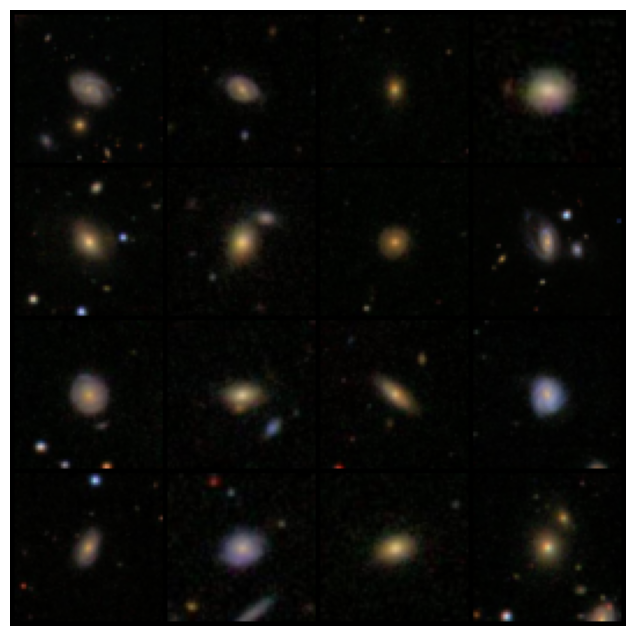

Labels:
tensor([1, 2, 0, 0, 0, 0, 1, 2, 1, 0, 1, 1, 1, 1, 0, 0])

Class names:
['spiral', 'spiral_barred', 'elliptical', 'elliptical', 'elliptical', 'elliptical', 'spiral', 'spiral_barred', 'spiral', 'elliptical', 'spiral', 'spiral', 'spiral', 'spiral', 'elliptical', 'elliptical']


In [ ]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
# Take first 16 images from the batch
grid = make_grid(images[:16] * 0.5 + 0.5, nrow=4)

plt.figure(figsize=(8,8))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.show()
print("Labels:")
print(labels[:16])

print("\nClass names:")
print([dataset.classes[i] for i in labels[:16]])

Reflection:

*1.The most confusing part was setting up the dataset paths in Google Colab and understanding where the images and CSV files were located. I resolved it by checking the folder structure, verifying the paths with Path.exists(), and making sure the images and label files were correctly extracted into Google Drive*.

*2.For a spiral galaxy, a CNN must learn to recognize the curved spiral arms extending from the center of the galaxy. It may also learn features such as the brightness distribution, central bulge, and overall shape that distinguish spirals from elliptical galaxies*.

*3. The hardest classes to distinguish are likely spiral and spiral_barred galaxies. Both contain spiral arms, and the difference is mainly the presence of a central bar structure, which can be difficult to see in small or low-resolution images*.

*4. A machine learning model can only learn effectively if the data is organized, labeled, and loaded correctly. Building a reliable data pipeline ensures that the model receives clean, consistent, and properly formatted inputs, which is essential for successful training and evaluation*.
